In [8]:
from neuron import h
import matplotlib.pyplot as plt
import numpy as np
import math
import time
import os
import pandas as pd
from scipy.signal import find_peaks
from impulse_generator import *
from MRG_lib import *
import h5py

In [9]:
stimulation_duration_ms = 10000.0           # 1 секунда
amp_nA = -1                            # амплитуда импульса
dt = 0.005                            # dt модели
v_init = -80.0
h_stop_ms = 10100.0                         # после стимуляции ещё хвост


ПАРАМЕТРЫ МОДЕЛИ

--- ОСНОВНЫЕ ПАРАМЕТРЫ ---
Диаметр волокна: 5.7 мкм
Температура: 37.0 °C
Шаг времени: 0.005 мс
Начальное напряжение: -80.0 мВ
Время симуляции: 10100.0 мс

--- ПАРАМЕТРЫ МОРФОЛОГИИ ---
Узлов в основном аксоне: 50
Узлов в ветви: 5
Количество ветвей: 5
Расстояние между ветвлениями: 10 сегментов
Масштаб диаметра: 0.6
Шаг ветвления (запрошенный): None мкм
Шаг ветвления (фактический): 5000.0 мкм

--- ПАРАМЕТРЫ MRG ДЛЯ ДАННОГО ДИАМЕТРА ---
Диаметр аксона: 3.4 мкм
Диаметр узла: 1.9 мкм
Диаметр MYSA: 1.9 мкм
Диаметр FLUT: 3.4 мкм
Длина MYSA: 3.0 мкм
Длина FLUT: 35 мкм
Длина интернода (STIN): 70.5 мкм
Шаг между узлами (Lstep): 500.0 мкм
Плотность натриевых каналов (g): N/A

--- ЭЛЕКТРИЧЕСКИЕ ПАРАМЕТРЫ ---
Удельное сопротивление аксоплазмы (rho_a): 700000.0 Ом·мкм
Ёмкость миелина (mycm): 0.1 мкФ/см²
Проводимость миелина (mygm): 0.001 См/см²
Проводимость натриевых каналов в узле: 3.0 См/см²
Масштаб проводимости nap: 0.5

[build_axon] Bifurcation at: node_10  |  dist≈5000.0 µm
[b

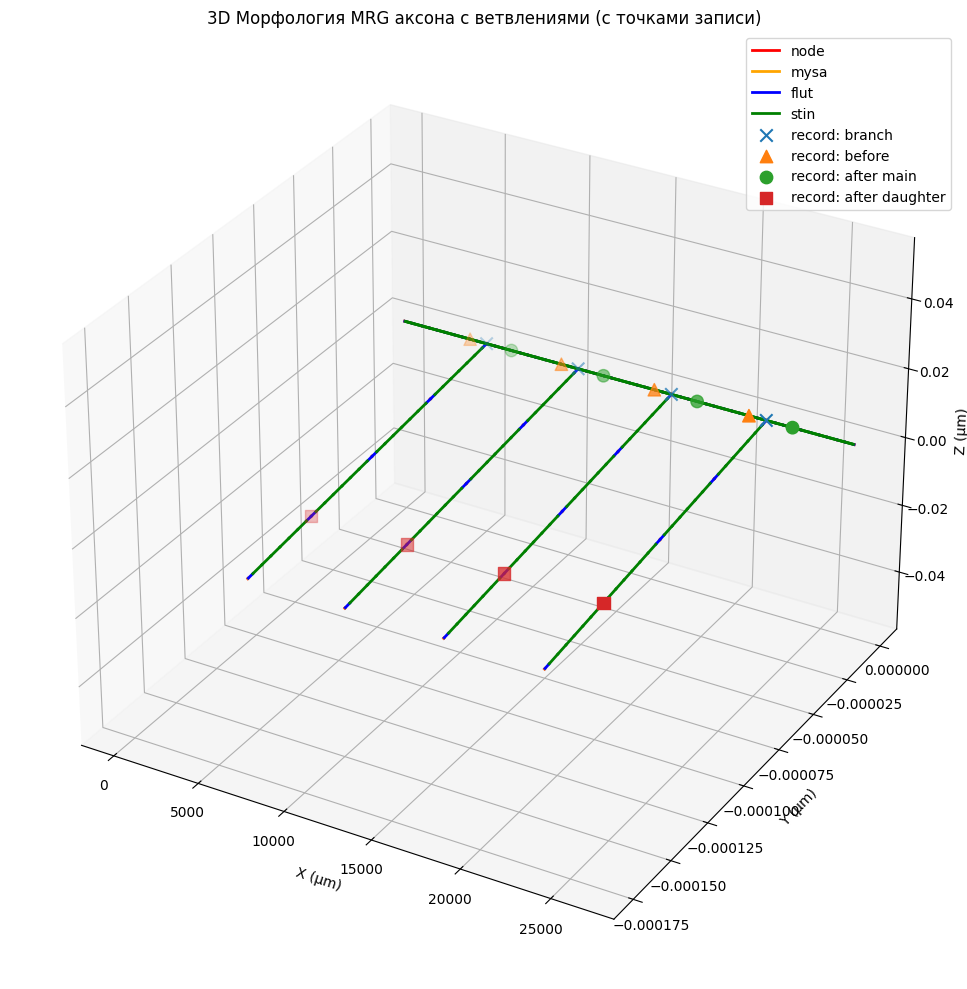

In [10]:



axon = MRGaxon(
    fiber_diameter=5.7,
    parent_axon_nodes=50,
    branch_nodes=5,
    branches_num=5,
    nodes_dist=10,
    diam_scale=0.6,
    celsius=37.0,
    dt_ms=dt,
    v_init=v_init,
    h_stop=h_stop_ms
)

axon.plot_morphology_3d()

In [13]:
axon.set_stimulation_params(mode='create',
                            freq_hz=1000,
                            amp=amp_nA,
                            t_start=10,
                            t_end=h_stop_ms,
                            phase_us=40.0,
                            gap_us=5,
                            plot_duration=1)

In [14]:
axon.run_simulation()


[create_stimulator] freq=1000 Гц:
[create_stimulator] Период: 1.000 мс
[create_stimulator] Ширина бифазного пакета: 0.085 мс [create_stimulator] (2×0.040 + 0.005)
[create_stimulator] Количество пульсов: 10090
[create_stimulator] Длительность стимуляции: 10090.0 мс


(array([0.0000000e+00, 5.0000000e-03, 1.0000000e-02, ..., 1.0089990e+04,
        1.0089995e+04, 1.0090000e+04], shape=(2018001,)),
 array([[-65.        , -65.35422083, -65.60359249, ..., -76.99997205,
         -77.00594649, -77.01200365],
        [-65.        , -65.3542113 , -65.60354912, ..., -77.17303762,
         -77.19969178, -77.22539586],
        [-65.        , -65.3542113 , -65.60354912, ..., -52.49202683,
         -53.2755986 , -54.04302797],
        ...,
        [-65.        , -65.42790078, -65.72446382, ..., -40.5499734 ,
         -41.55957264, -42.55310789],
        [-65.        , -65.42790079, -65.72446385, ..., -79.990329  ,
         -79.92656195, -79.85325512],
        [-65.        , -65.42258279, -65.71931766, ..., -77.66673365,
         -77.67174446, -86.04629653]], shape=(17, 2018001)))

Индексы для построения:
  До ветвления: [0, 1, 2, 3]
  После ветвления (основная): [4, 5, 6, 7]
  После ветвления (дочерняя): [8, 9, 10, 11]


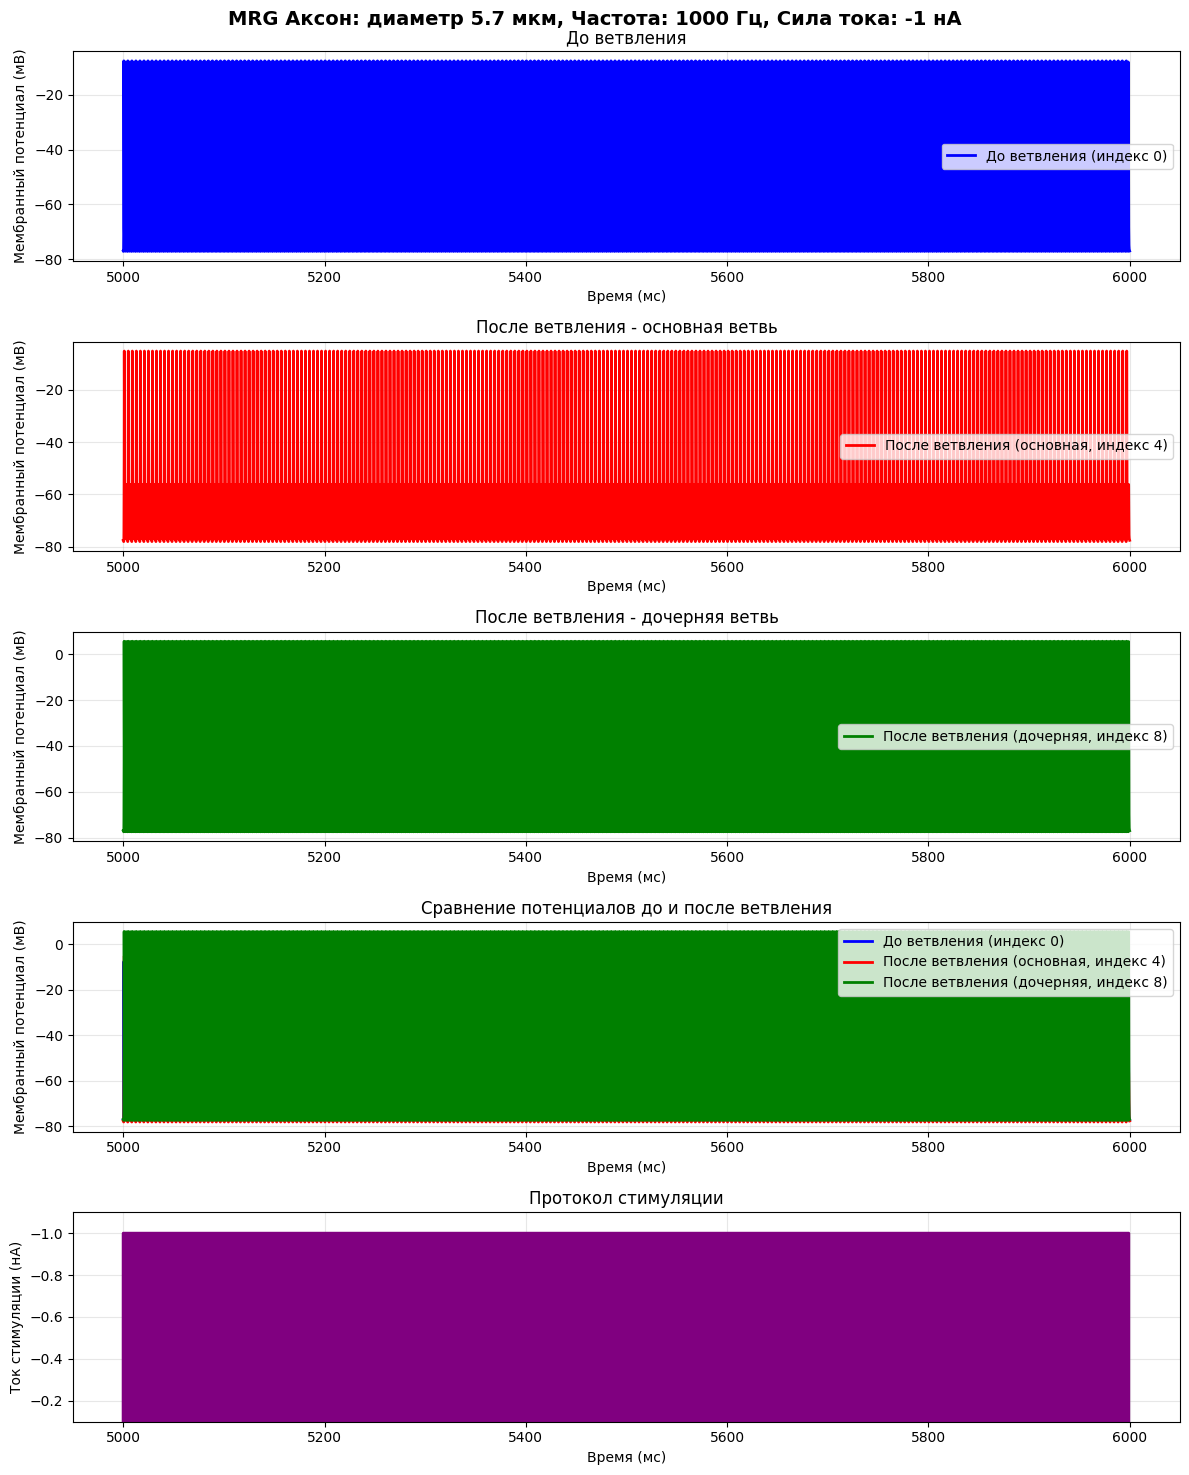

Индексы для построения:
  До ветвления: [0, 1, 2, 3]
  После ветвления (основная): [4, 5, 6, 7]
  После ветвления (дочерняя): [8, 9, 10, 11]


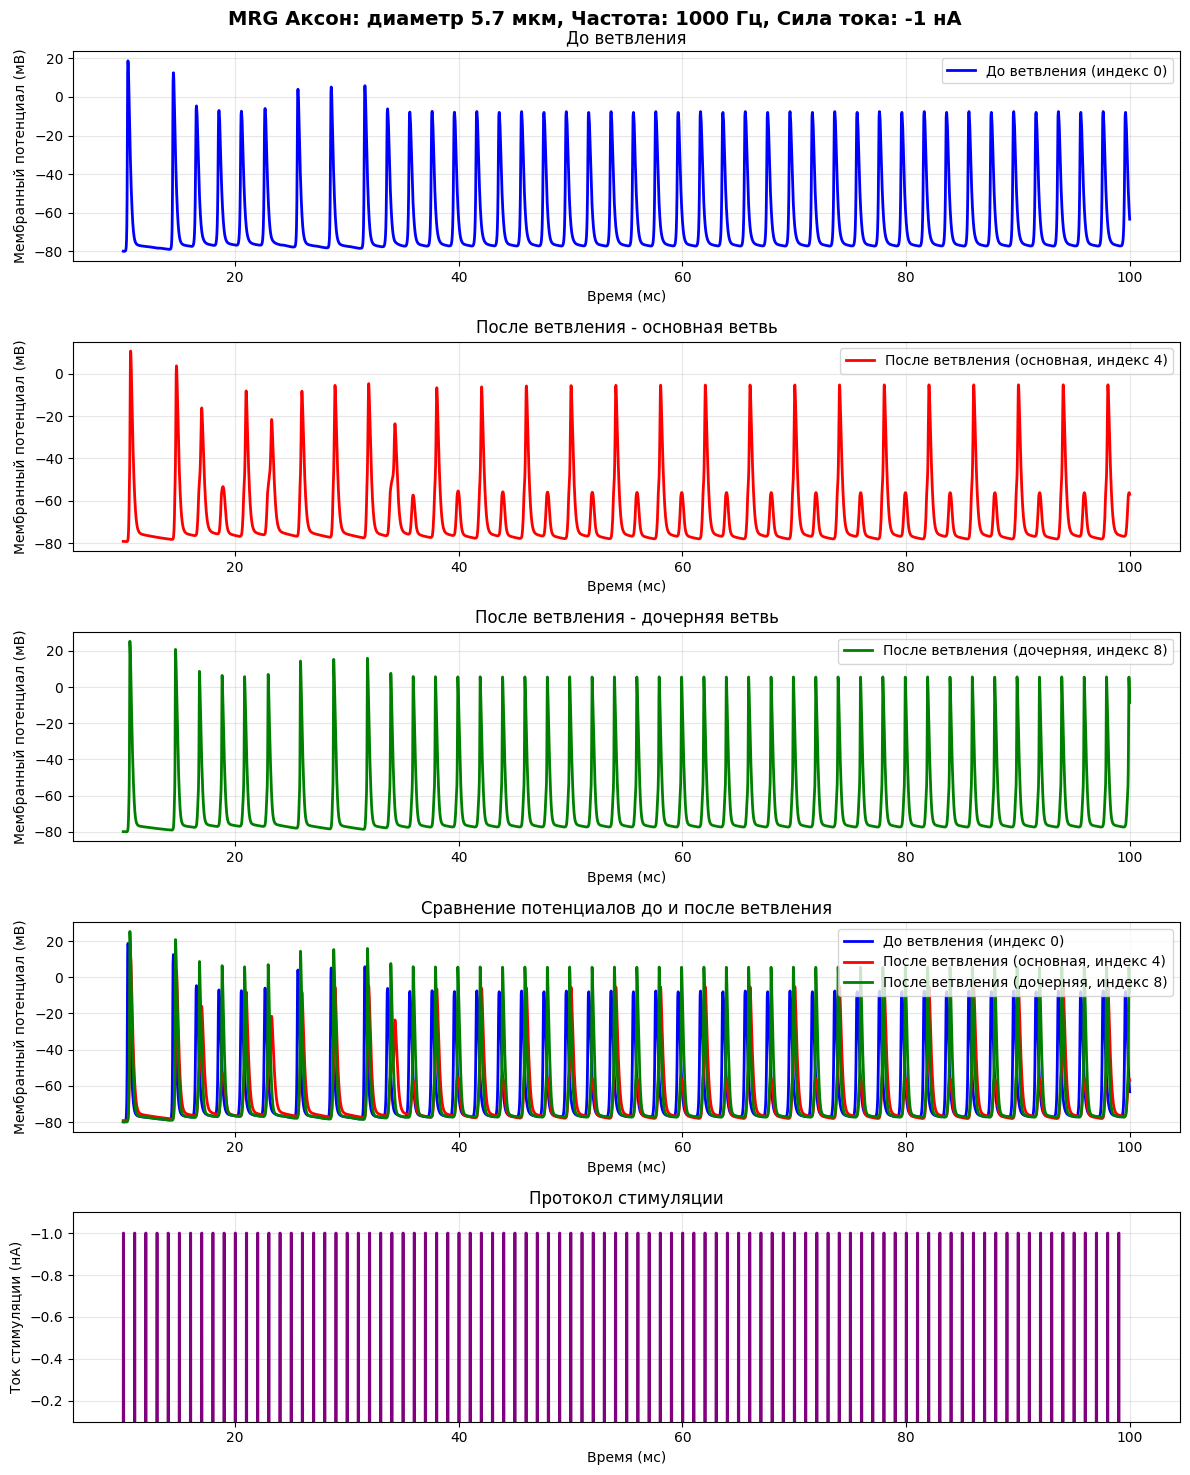

Индексы для построения:
  До ветвления: [0, 1, 2, 3]
  После ветвления (основная): [4, 5, 6, 7]
  После ветвления (дочерняя): [8, 9, 10, 11]


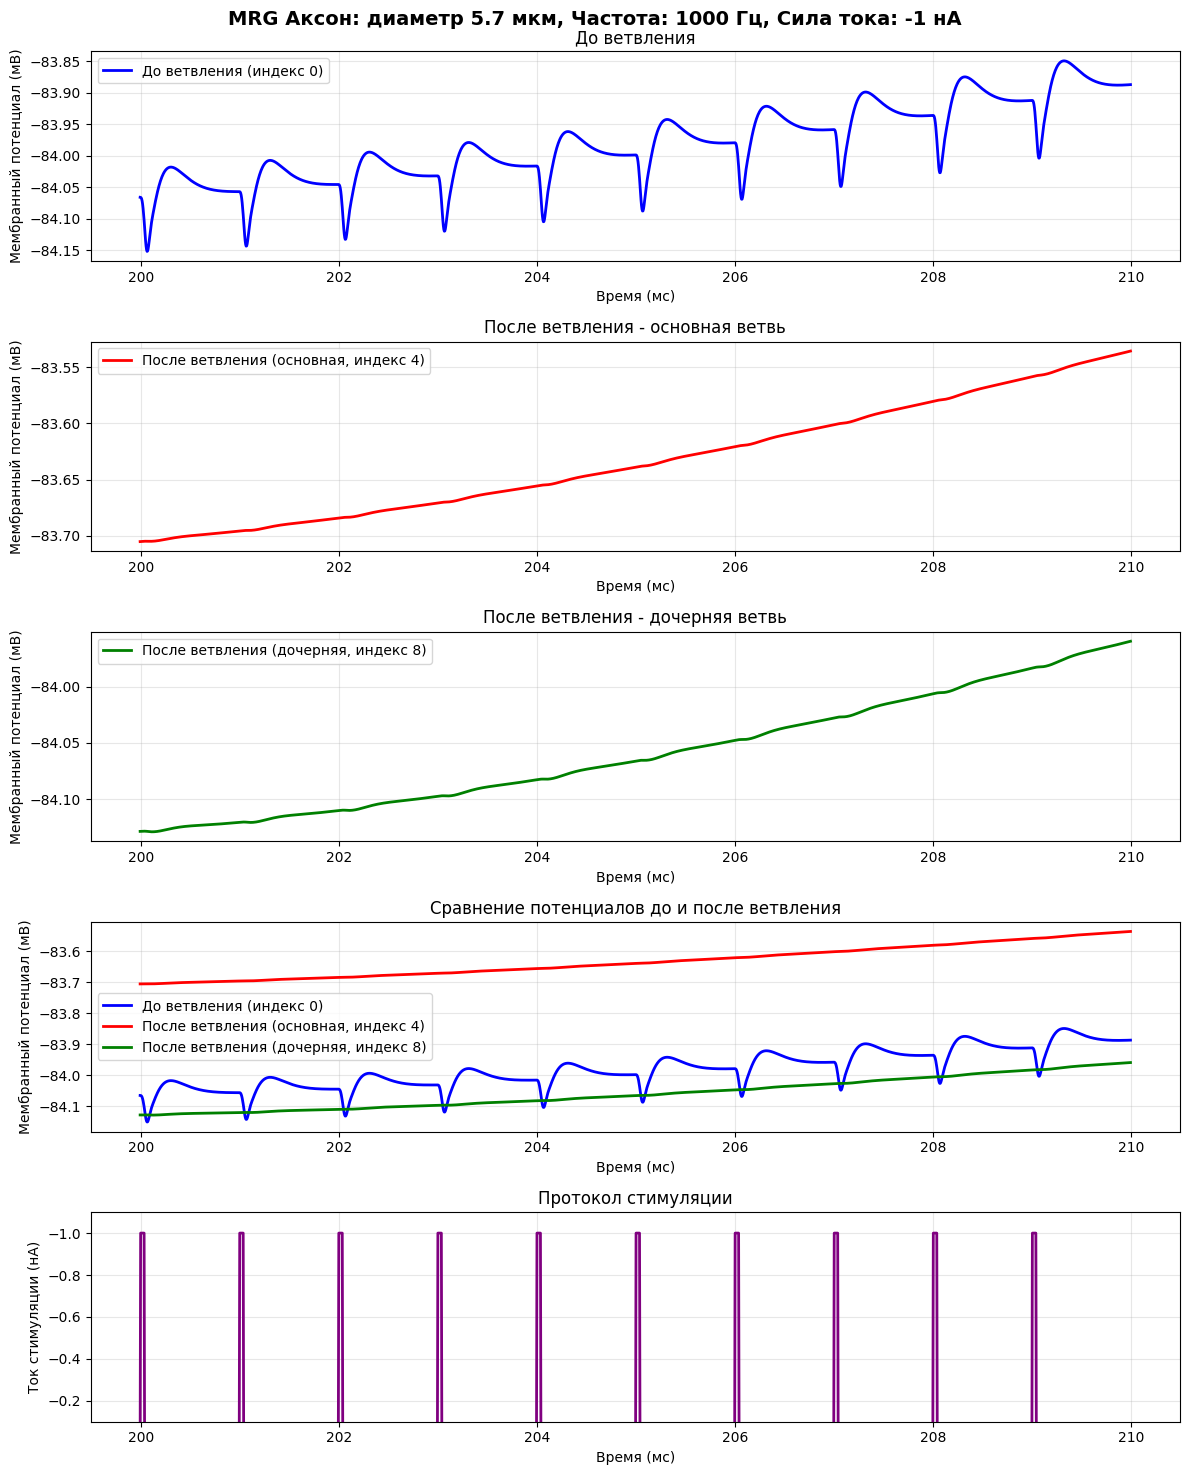

Индексы для построения:
  До ветвления: [0, 1, 2, 3]
  После ветвления (основная): [4, 5, 6, 7]
  После ветвления (дочерняя): [8, 9, 10, 11]


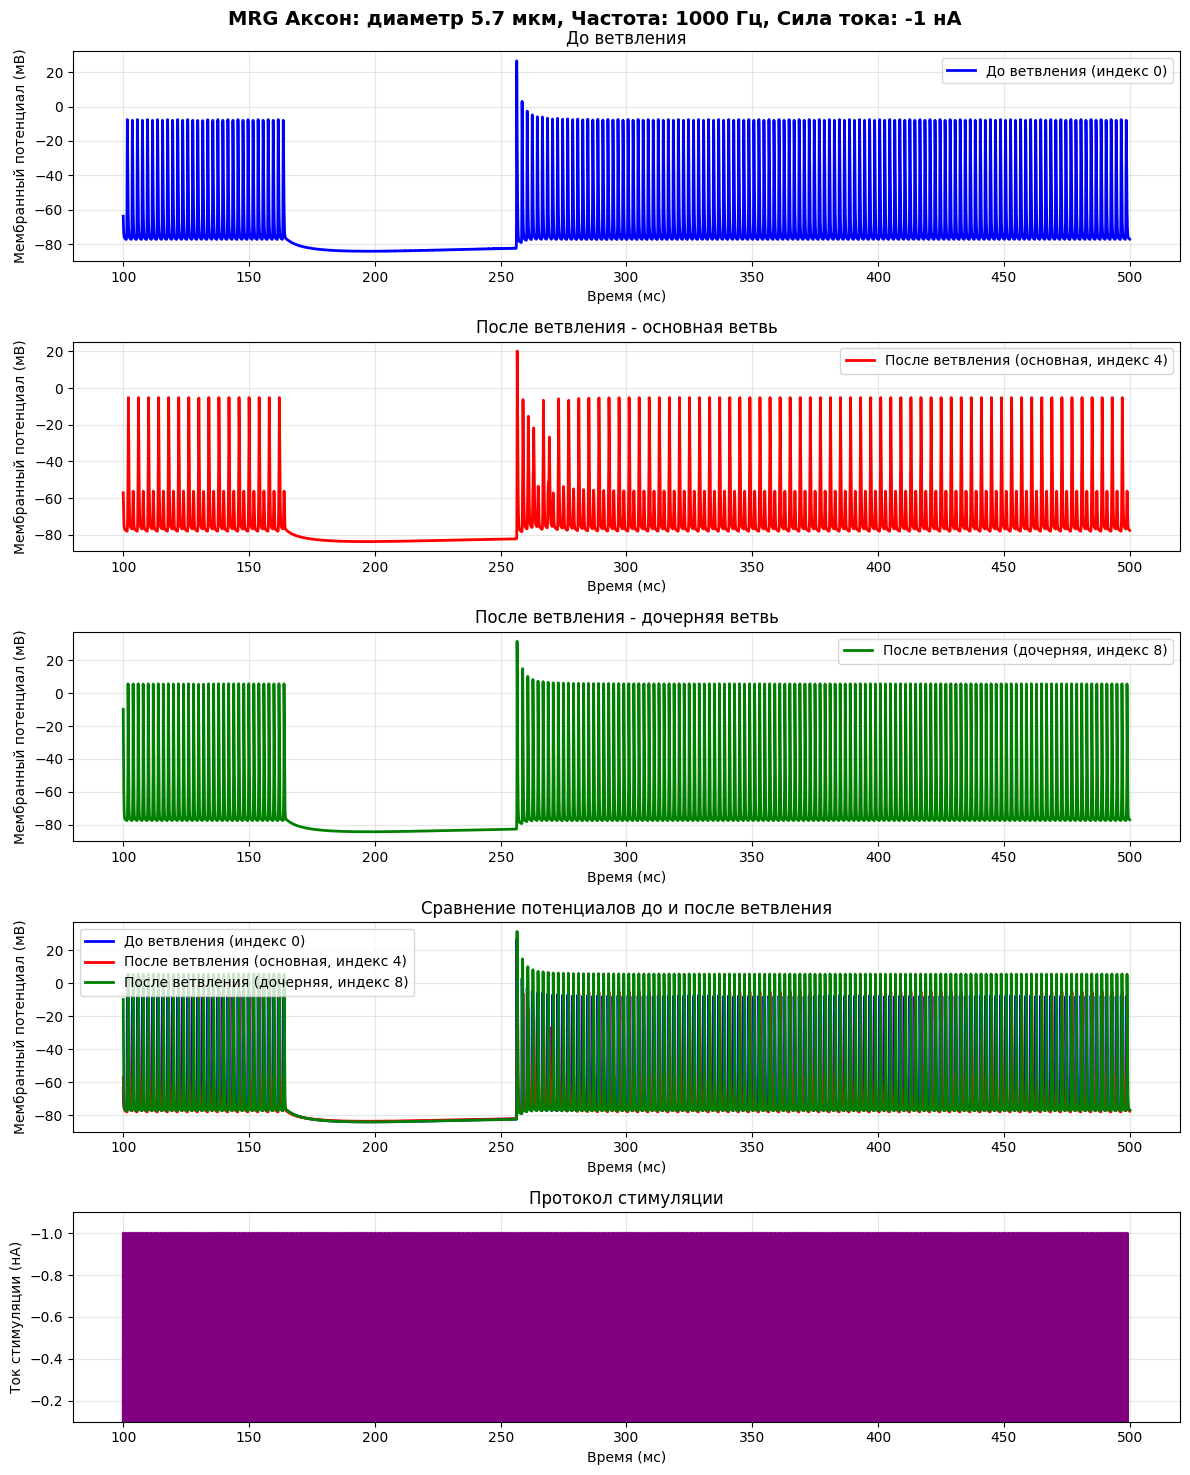

Индексы для построения:
  До ветвления: [0, 1, 2, 3]
  После ветвления (основная): [4, 5, 6, 7]
  После ветвления (дочерняя): [8, 9, 10, 11]


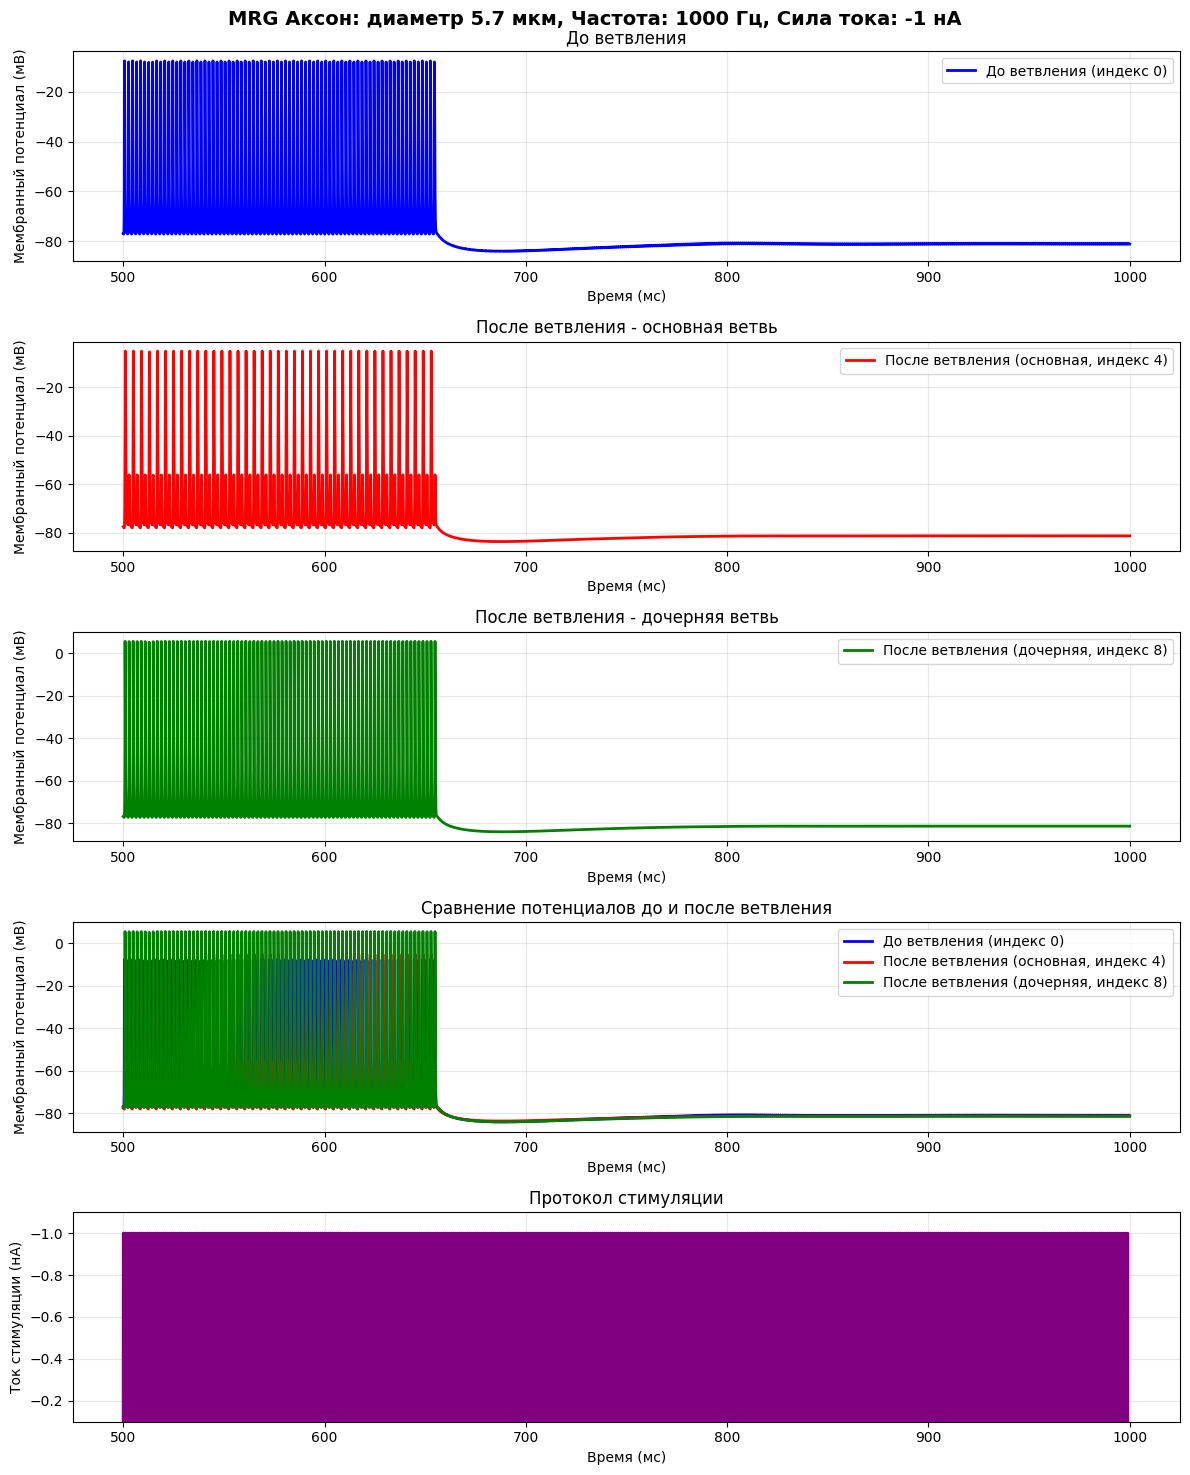

In [15]:

plot_start = int(5000 // dt)
plot_end = int(6000 // dt)

axon.plot_voltage_traces(plot_start =plot_start, plot_end=plot_end, plot_branch=0)

plot_start = int(10 // dt)
plot_end = int(100 // dt)

axon.plot_voltage_traces(plot_start =plot_start, plot_end=plot_end, plot_branch=0)

plot_start = int(200 // dt)
plot_end = int(210 // dt)

axon.plot_voltage_traces(plot_start =plot_start, plot_end=plot_end, plot_branch=0)

plot_start = int(100 // dt)
plot_end = int(500 // dt)

axon.plot_voltage_traces(plot_start =plot_start, plot_end=plot_end, plot_branch=0)

plot_start = int(500 // dt)
plot_end = int(1000 // dt)

axon.plot_voltage_traces(plot_start =plot_start, plot_end=plot_end, plot_branch=0)


In [ ]:
plot_start = int(0 // dt)
plot_end = int(10000 // dt)

axon.plot_voltage_traces(plot_start =plot_start, plot_end=plot_end, plot_branch=0)

Индексы для построения:
  До ветвления: [0, 1, 2, 3]
  После ветвления (основная): [4, 5, 6, 7]
  После ветвления (дочерняя): [8, 9, 10, 11]


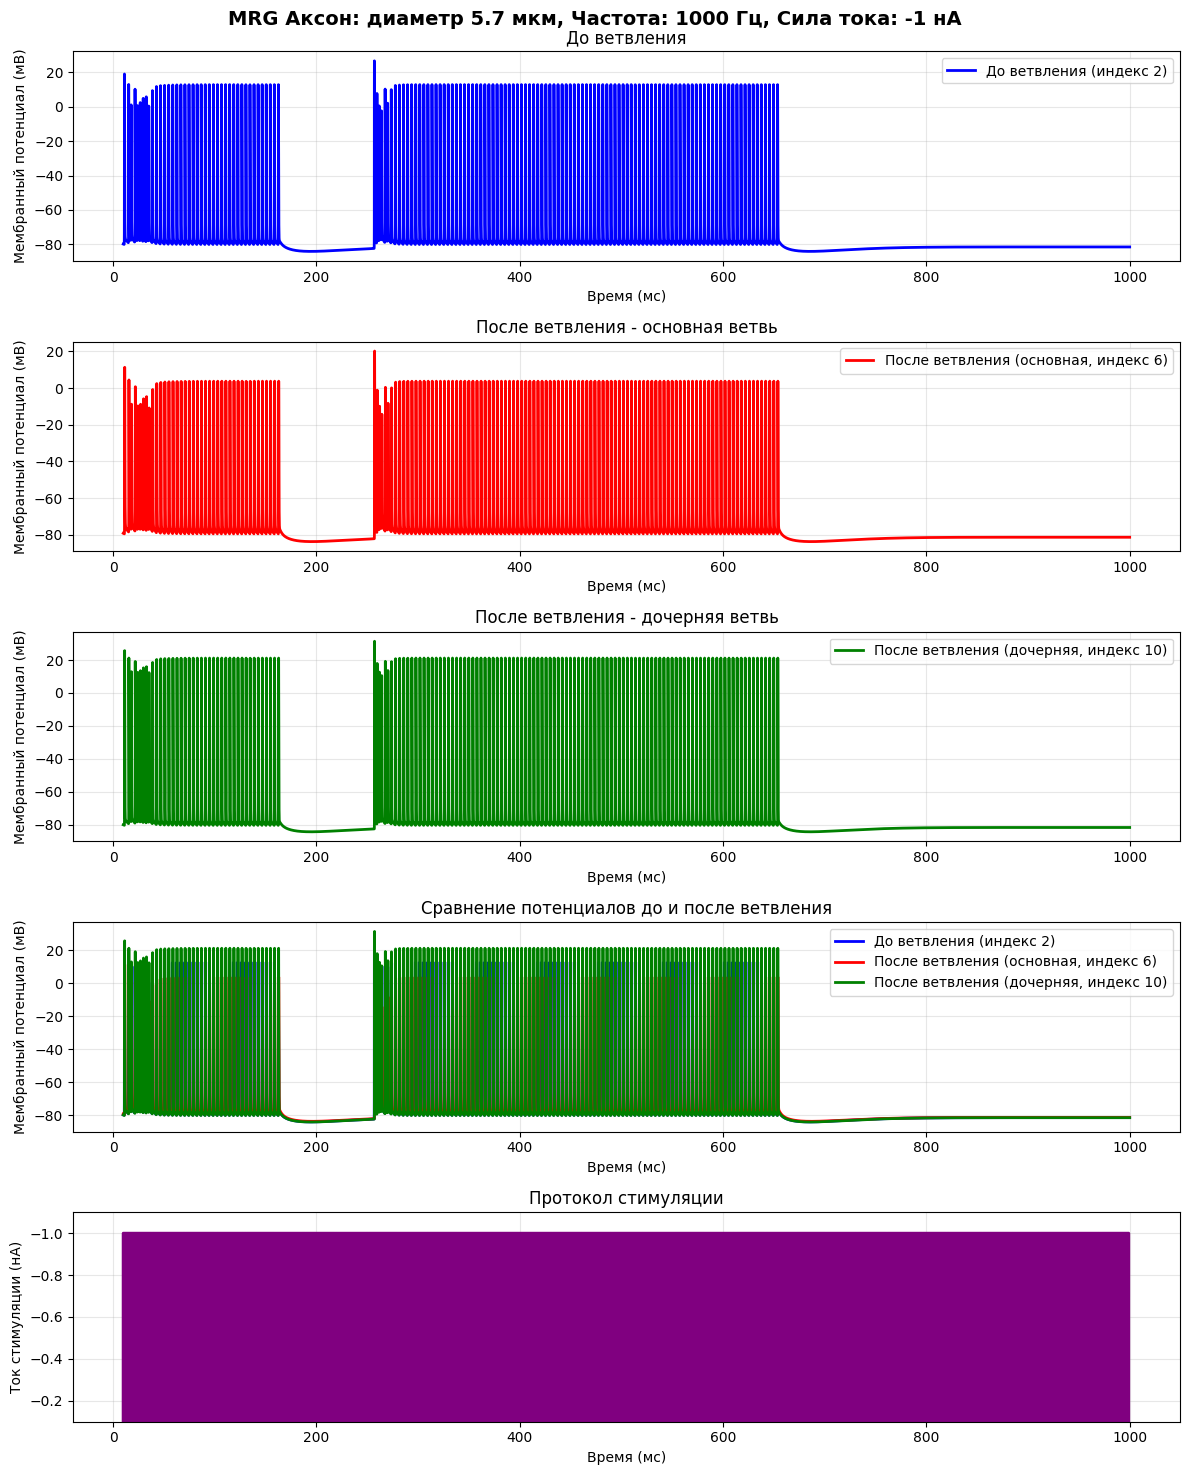

Индексы для построения:
  До ветвления: [0, 1, 2, 3]
  После ветвления (основная): [4, 5, 6, 7]
  После ветвления (дочерняя): [8, 9, 10, 11]


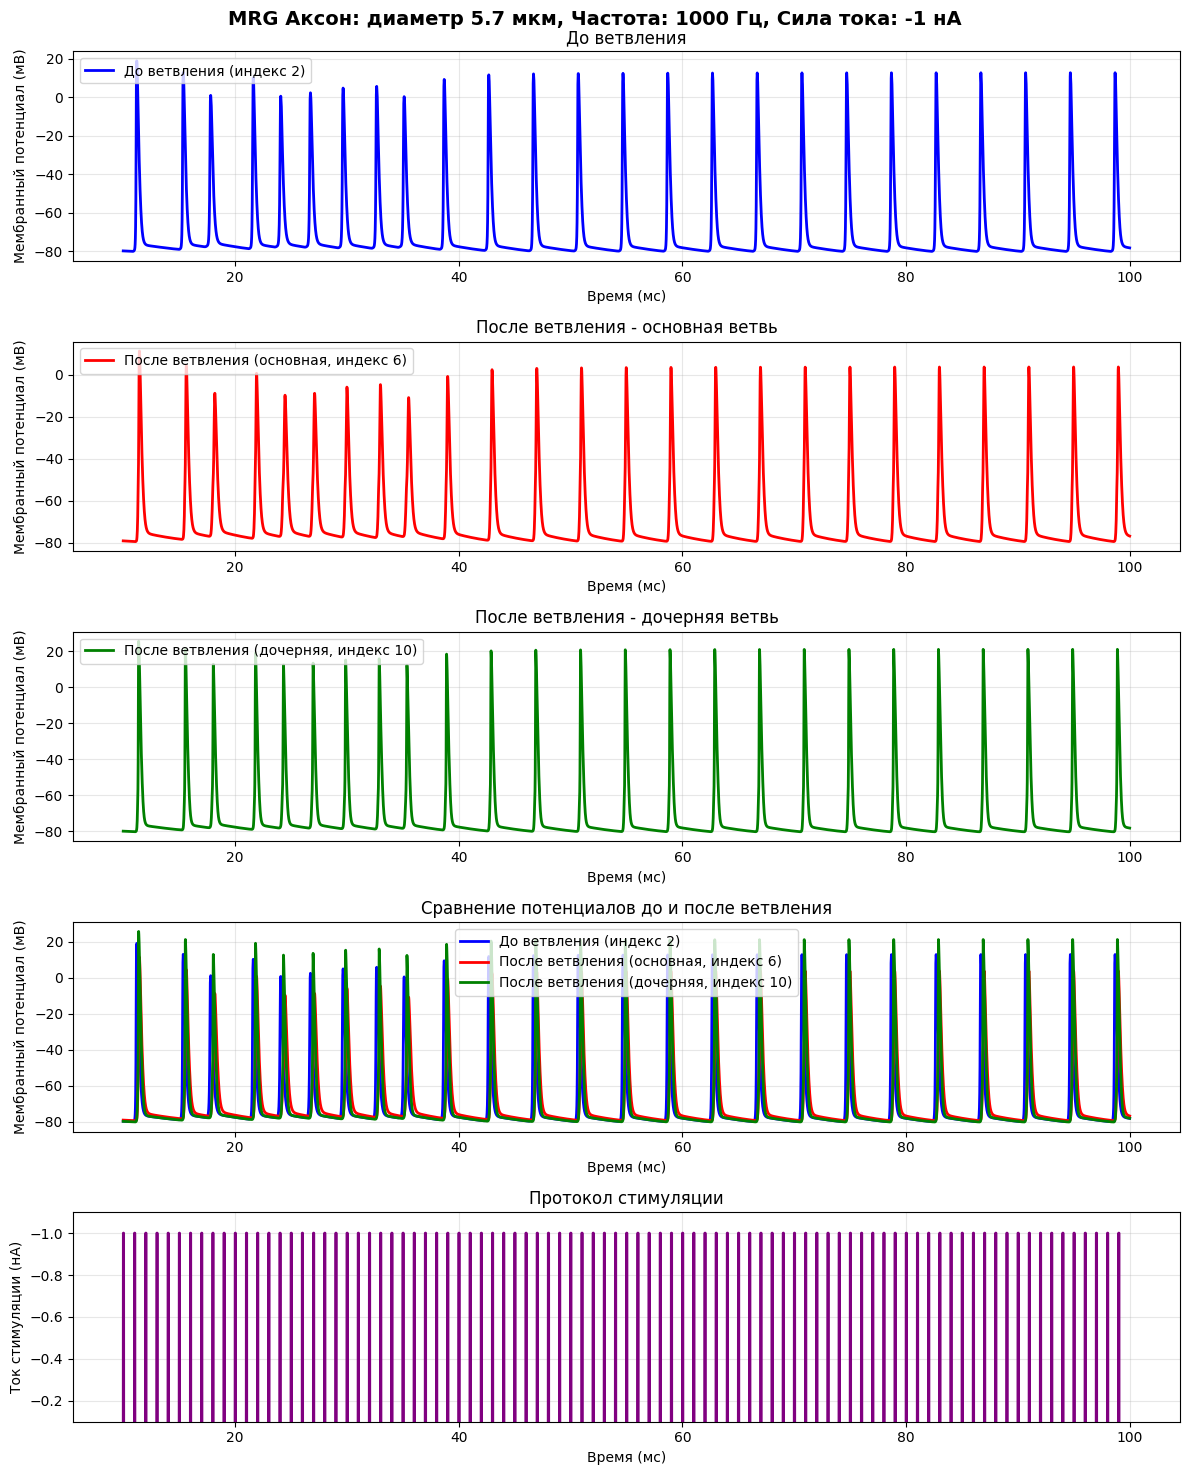

Индексы для построения:
  До ветвления: [0, 1, 2, 3]
  После ветвления (основная): [4, 5, 6, 7]
  После ветвления (дочерняя): [8, 9, 10, 11]


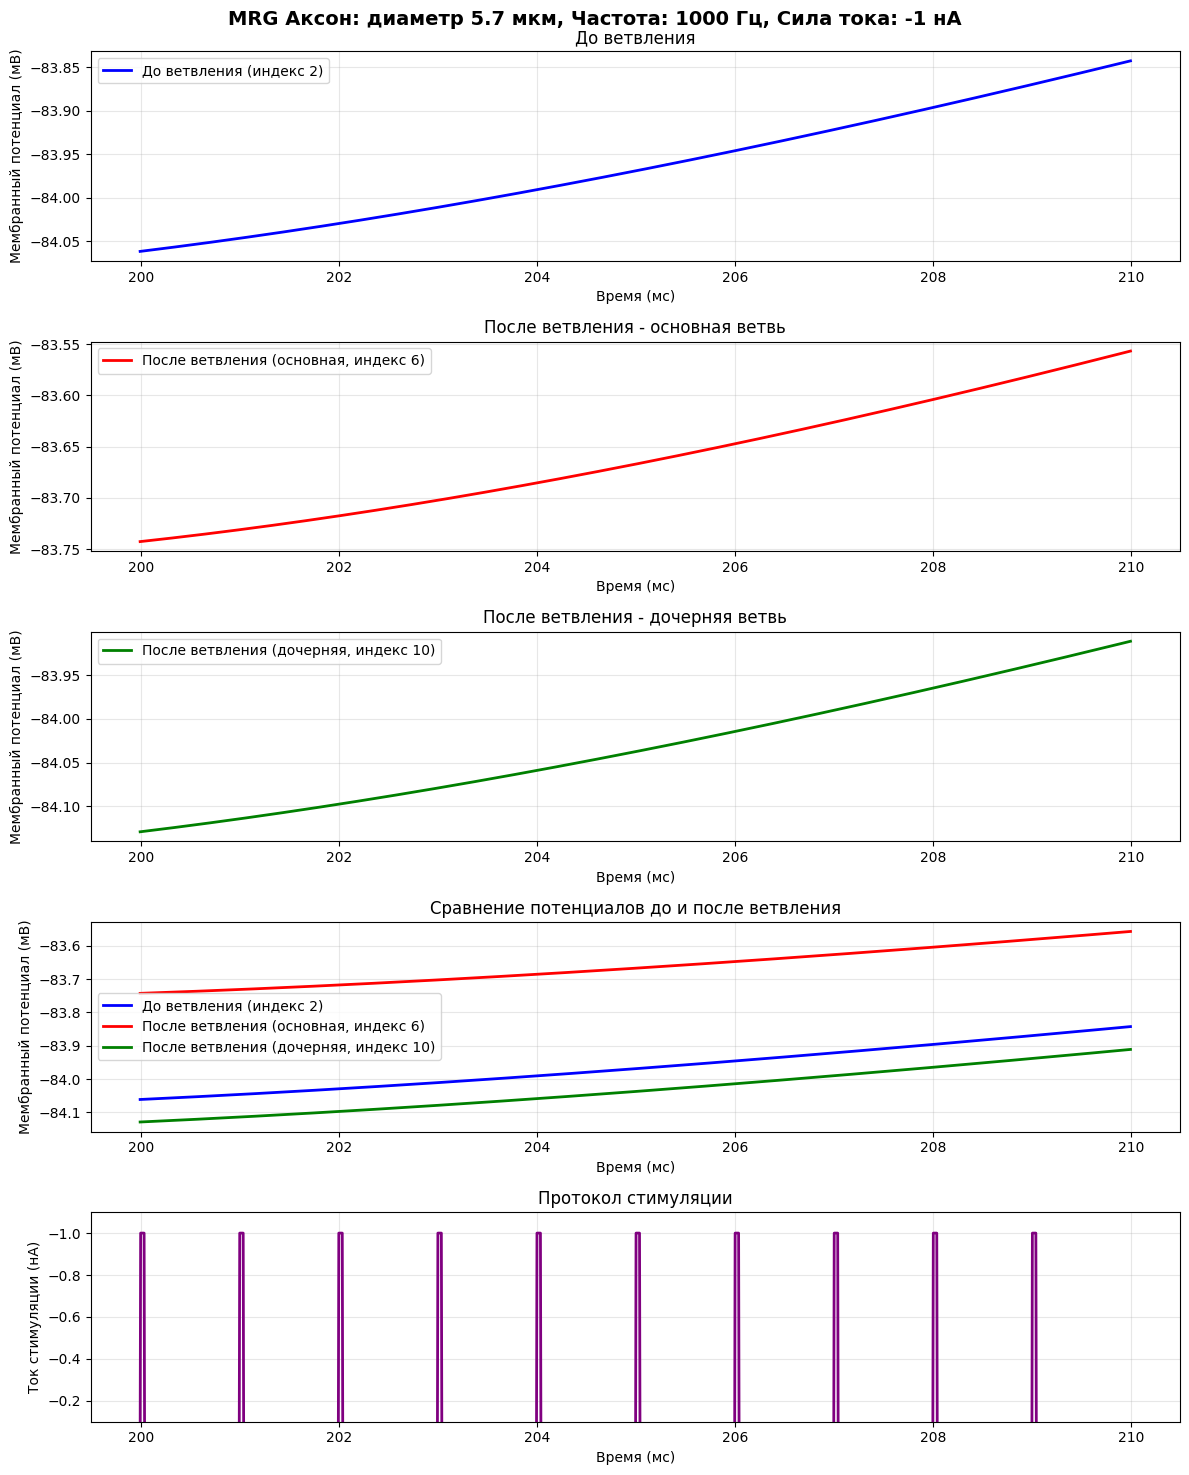

Индексы для построения:
  До ветвления: [0, 1, 2, 3]
  После ветвления (основная): [4, 5, 6, 7]
  После ветвления (дочерняя): [8, 9, 10, 11]


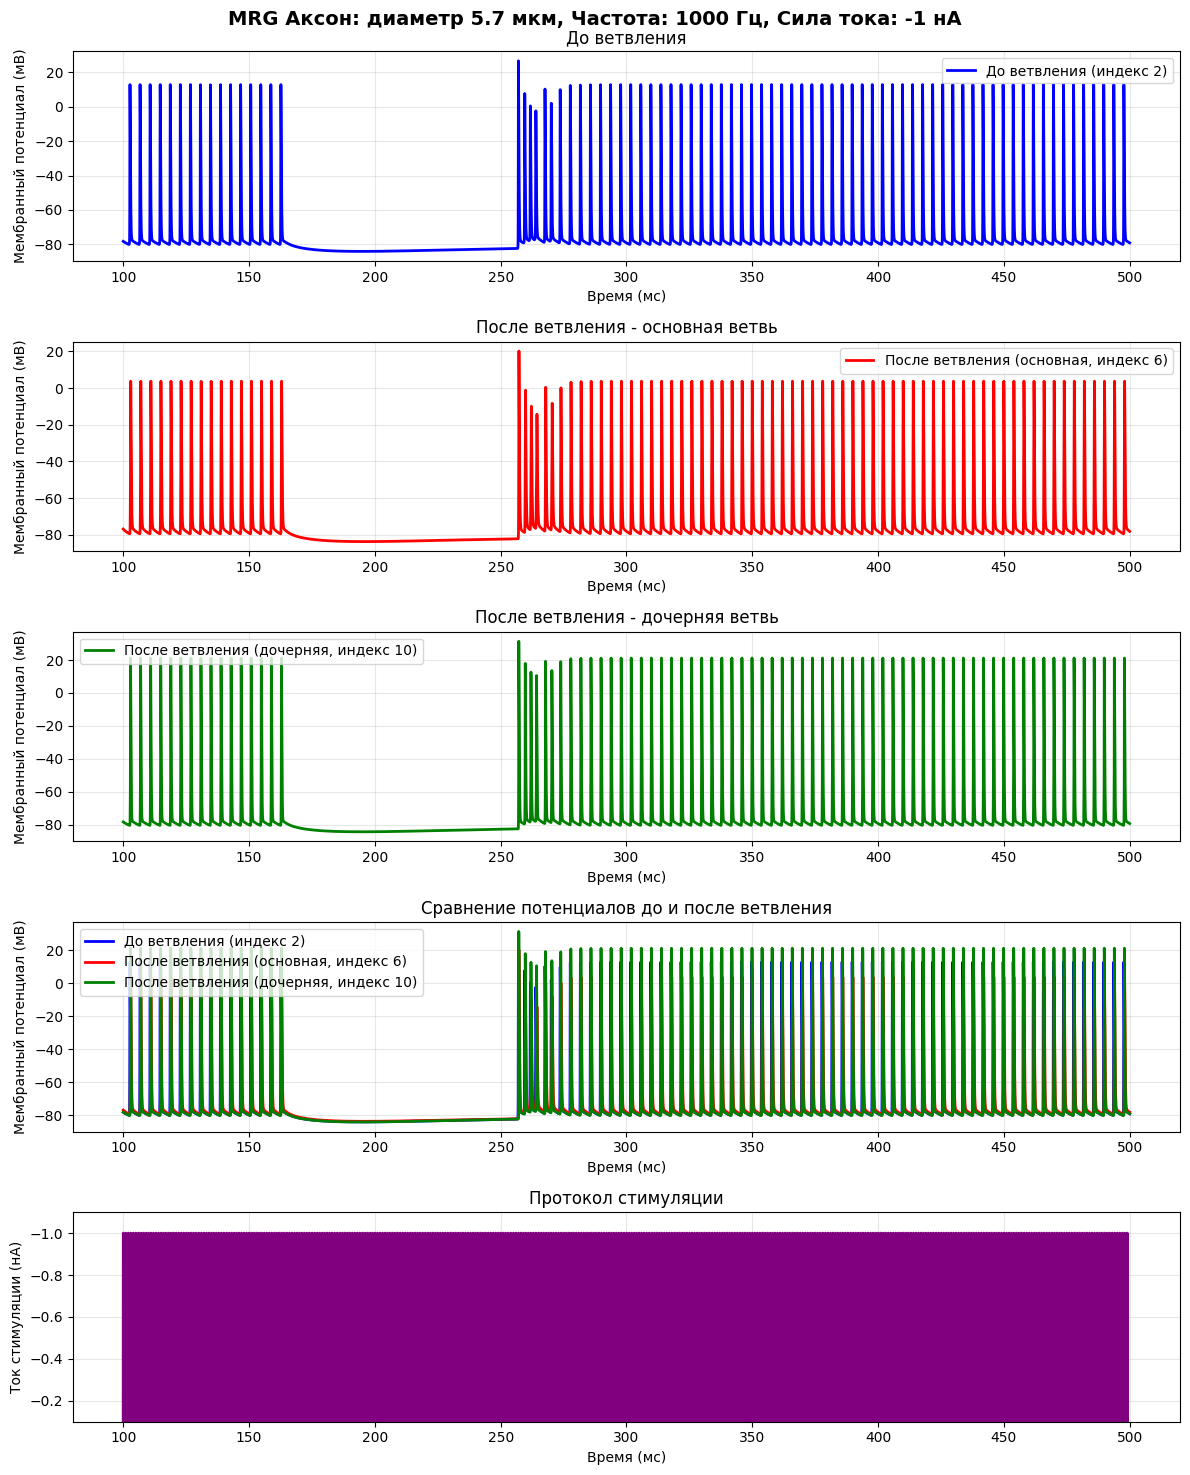

Индексы для построения:
  До ветвления: [0, 1, 2, 3]
  После ветвления (основная): [4, 5, 6, 7]
  После ветвления (дочерняя): [8, 9, 10, 11]


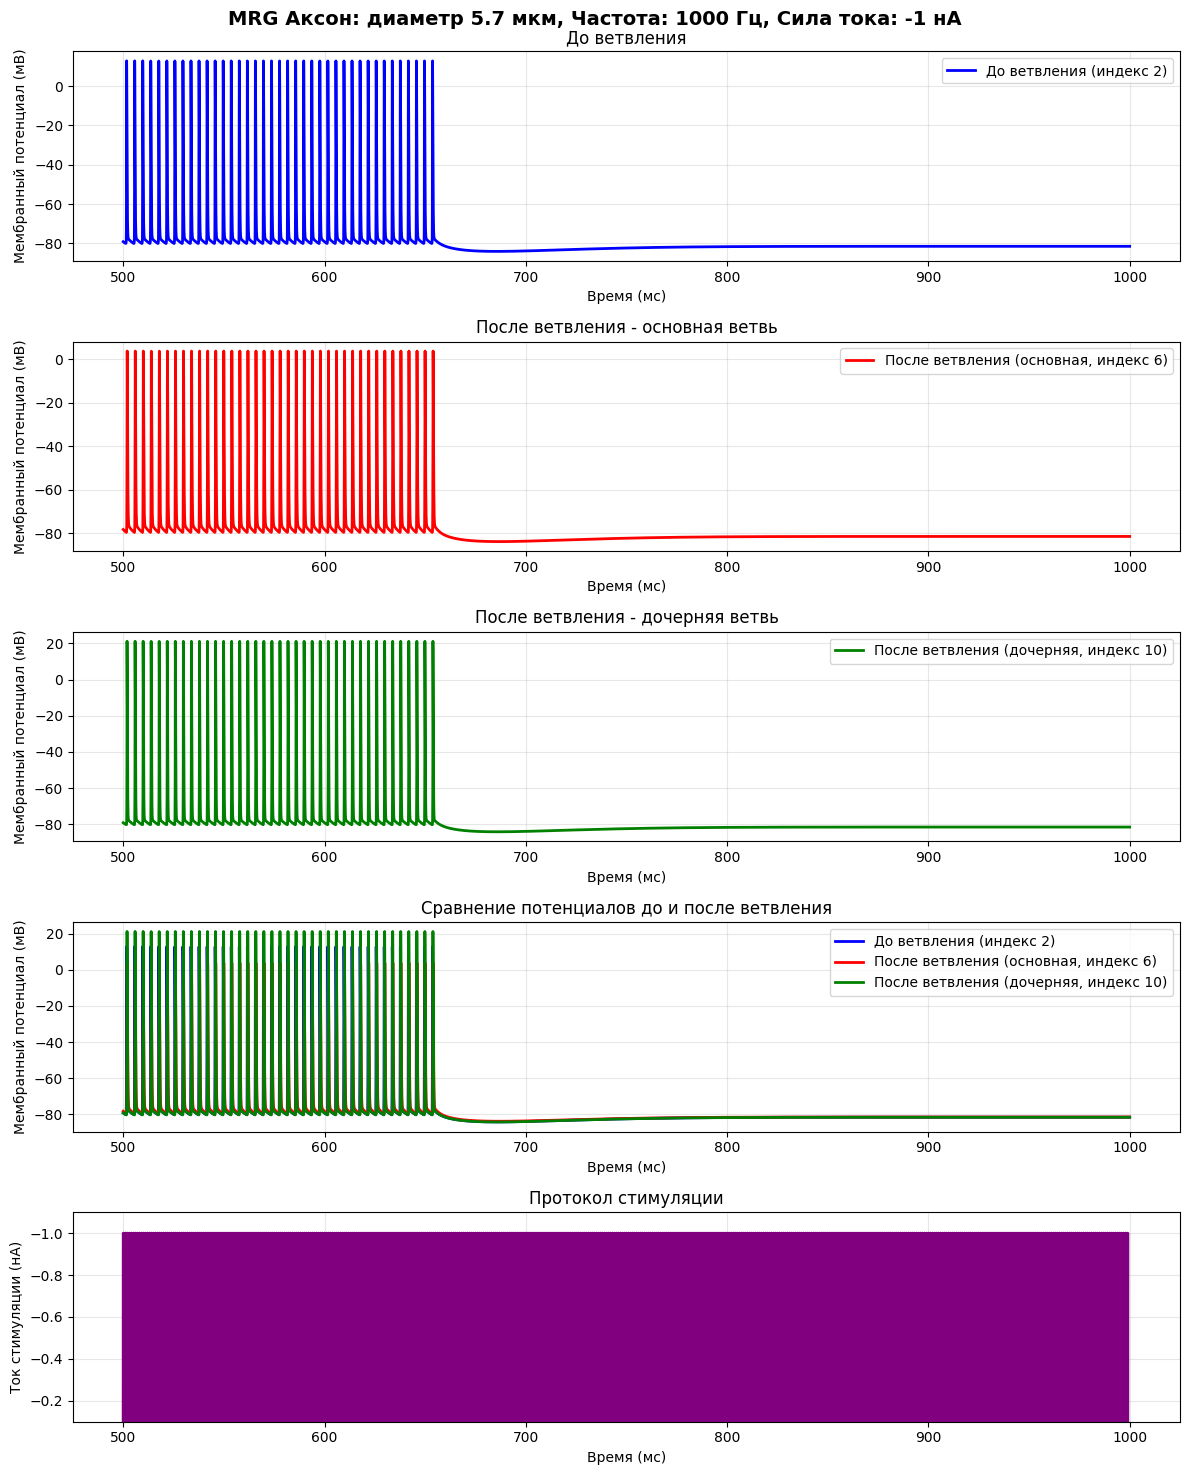

In [16]:
branch = 2

plot_start = int(10 // dt)
plot_end = int(1000 // dt)

axon.plot_voltage_traces(plot_start =plot_start, plot_end=plot_end, plot_branch=branch)

plot_start = int(10 // dt)
plot_end = int(100 // dt)

axon.plot_voltage_traces(plot_start =plot_start, plot_end=plot_end, plot_branch=branch)

plot_start = int(200 // dt)
plot_end = int(210 // dt)

axon.plot_voltage_traces(plot_start =plot_start, plot_end=plot_end, plot_branch=branch)

plot_start = int(100 // dt)
plot_end = int(500 // dt)

axon.plot_voltage_traces(plot_start =plot_start, plot_end=plot_end, plot_branch=branch)

plot_start = int(500 // dt)
plot_end = int(1000 // dt)

axon.plot_voltage_traces(plot_start =plot_start, plot_end=plot_end, plot_branch=branch)
